# ***Importing Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [ ]:
df = pd.read_csv("Train.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [ ]:
df.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [ ]:
df.shape

(8523, 12)

In [ ]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [ ]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [ ]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
Item_Identifier,8523,1559,FDW13,10
Item_Fat_Content,8523,5,Low Fat,5089
Item_Type,8523,16,Fruits and Vegetables,1232
Outlet_Identifier,8523,10,OUT027,935
Outlet_Size,6113,3,Medium,2793
Outlet_Location_Type,8523,3,Tier 3,3350
Outlet_Type,8523,4,Supermarket Type1,5577


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()/df.shape[0]*100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


In [ ]:
(df == 0).sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,526
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [ ]:
num_df = df.select_dtypes(include="number")
cat_df = df.select_dtypes(include="object")

In [ ]:
num_df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0,9.30,0.016047,249.8092,1999,3735.1380
1,5.92,0.019278,48.2692,2009,443.4228
2,17.50,0.016760,141.6180,1999,2097.2700
3,19.20,0.000000,182.0950,1998,732.3800
4,8.93,0.000000,53.8614,1987,994.7052


In [ ]:
num_df.corr()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.014048,0.027141,-0.011588,0.014123
Item_Visibility,-0.014048,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.027141,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.011588,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.014123,-0.128625,0.567574,-0.049135,1.000000


In [ ]:
num_df.cov()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,21.561688,-0.003172,7.865693,-0.354551,1.005608e+02
Item_Visibility,-0.003172,0.002662,-0.004225,-0.032325,-1.132561e+01
Item_MRP,7.865693,-0.004225,3878.183909,2.617143,6.031749e+04
Outlet_Establishment_Year,-0.354551,-0.032325,2.617143,70.086372,-7.019621e+02
Item_Outlet_Sales,100.560811,-11.325611,60317.485612,-701.962133,2.912141e+06


In [ ]:
num_df.kurtosis()

,0
Item_Weight,-1.227766
Item_Visibility,1.679445
Item_MRP,-0.889769
Outlet_Establishment_Year,-1.205694
Item_Outlet_Sales,1.615877


In [ ]:
num_df.quantile([0.25,0.5,0.75,0.95,0.99])

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0.25,8.77375,0.026989,93.82650,1987.0,834.24740
0.50,12.60000,0.053931,143.01280,1999.0,1794.33100
0.75,16.85000,0.094585,185.64370,2004.0,3101.29640
0.95,20.25000,0.163780,250.76924,2009.0,5522.81100
0.99,20.85000,0.226249,263.02260,2009.0,7366.01172


In [ ]:
cat_df.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1
3,FDX07,Regular,Fruits and Vegetables,OUT010,NaN,Tier 3,Grocery Store
4,NCD19,Low Fat,Household,OUT013,High,Tier 3,Supermarket Type1


In [ ]:
cat_df.drop(["Item_Identifier","Outlet_Identifier"], axis=1, inplace=True)



In [ ]:
cat_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [ ]:
df['Item_Type'].value_counts()

,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


In [ ]:
df['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


In [ ]:
df['Outlet_Size'].value_counts()

,count
Outlet_Size,
Medium,2793
Small,2388
High,932


# *Data Visaulization*

<Axes: >

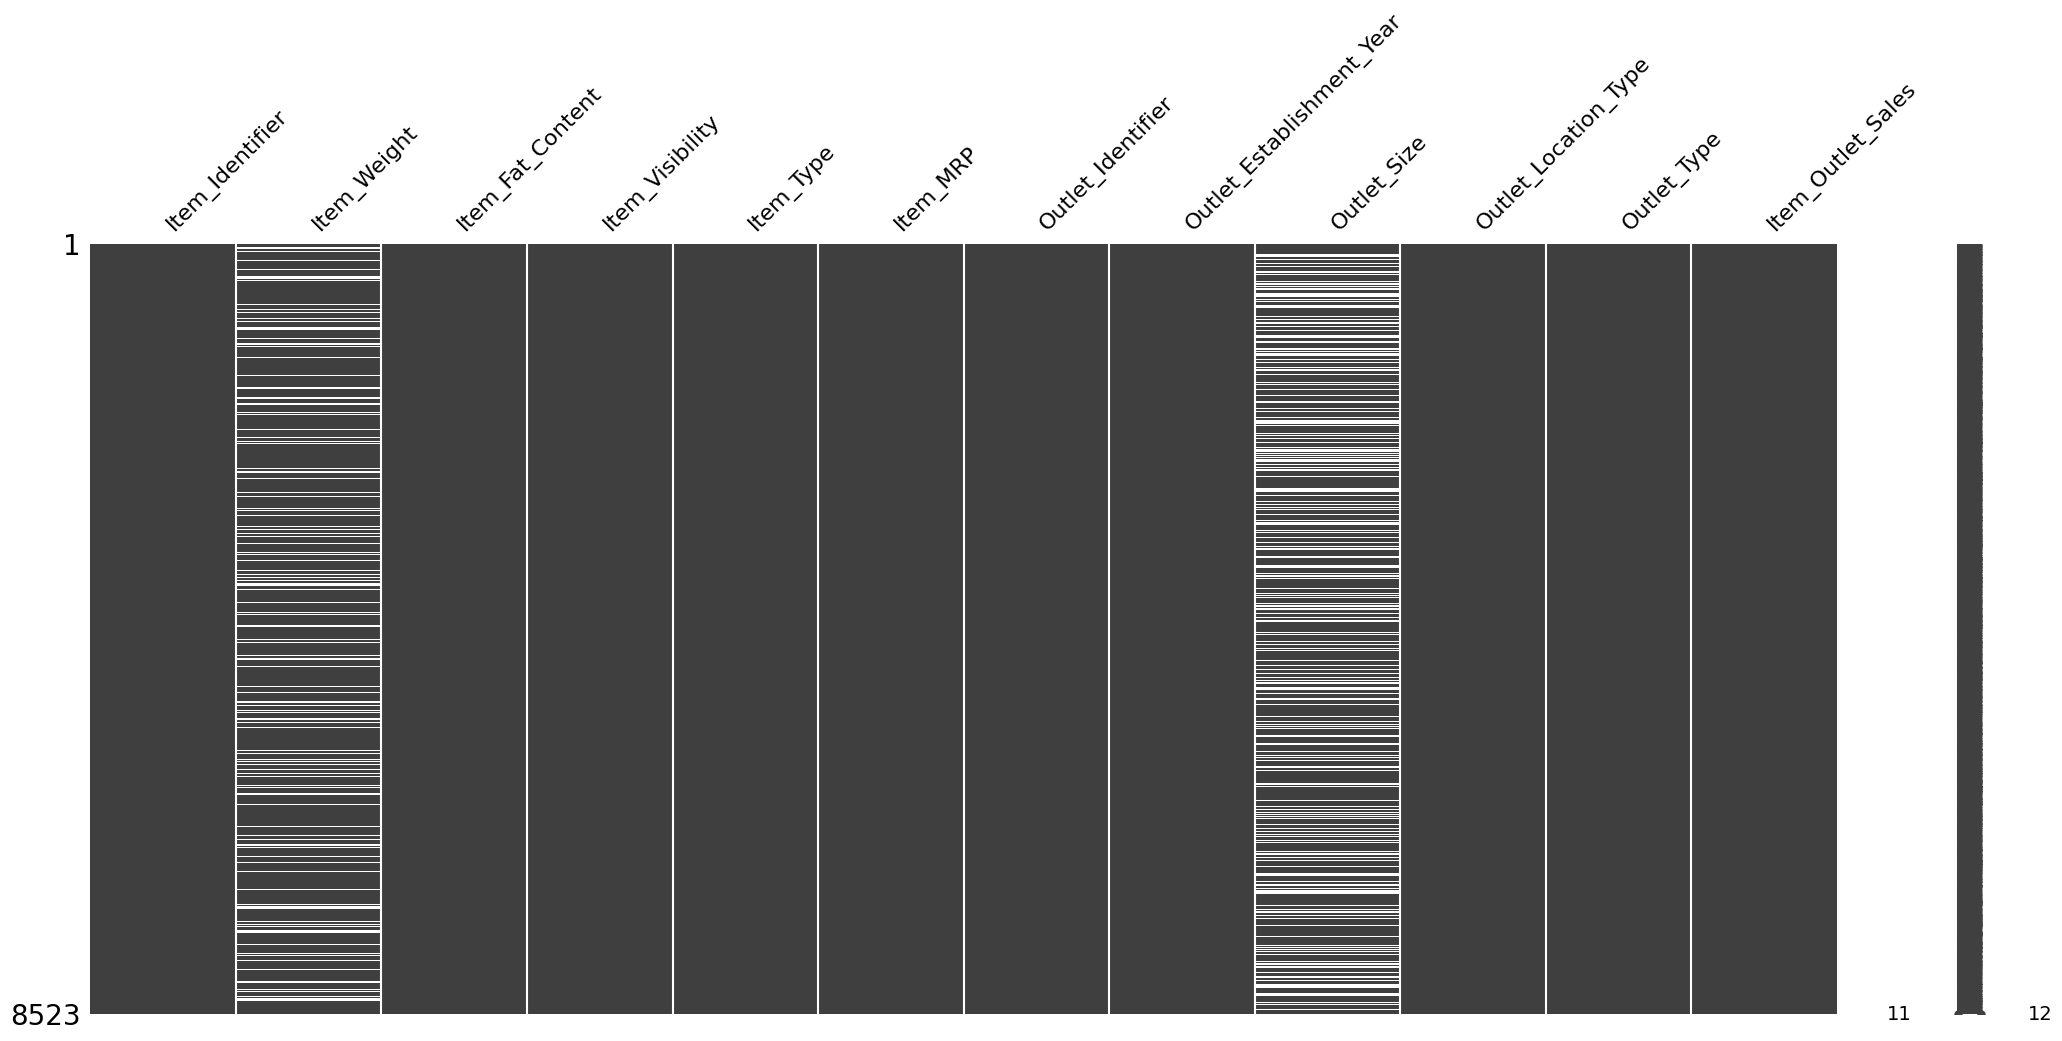

In [ ]:
import missingno
missingno.matrix(df)

<Axes: >

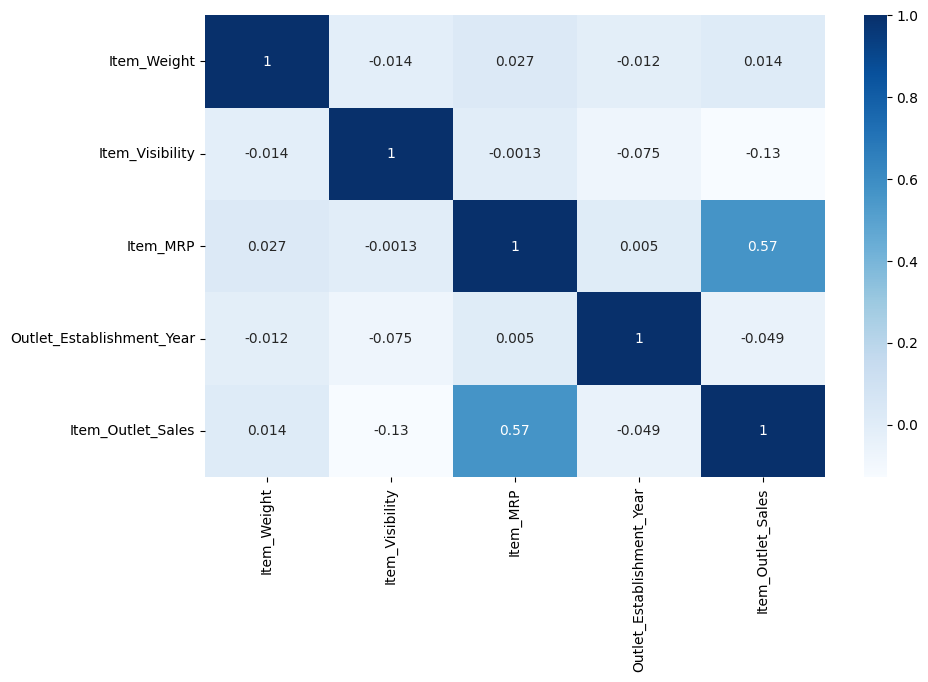

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(), annot=True, cmap="Blues")

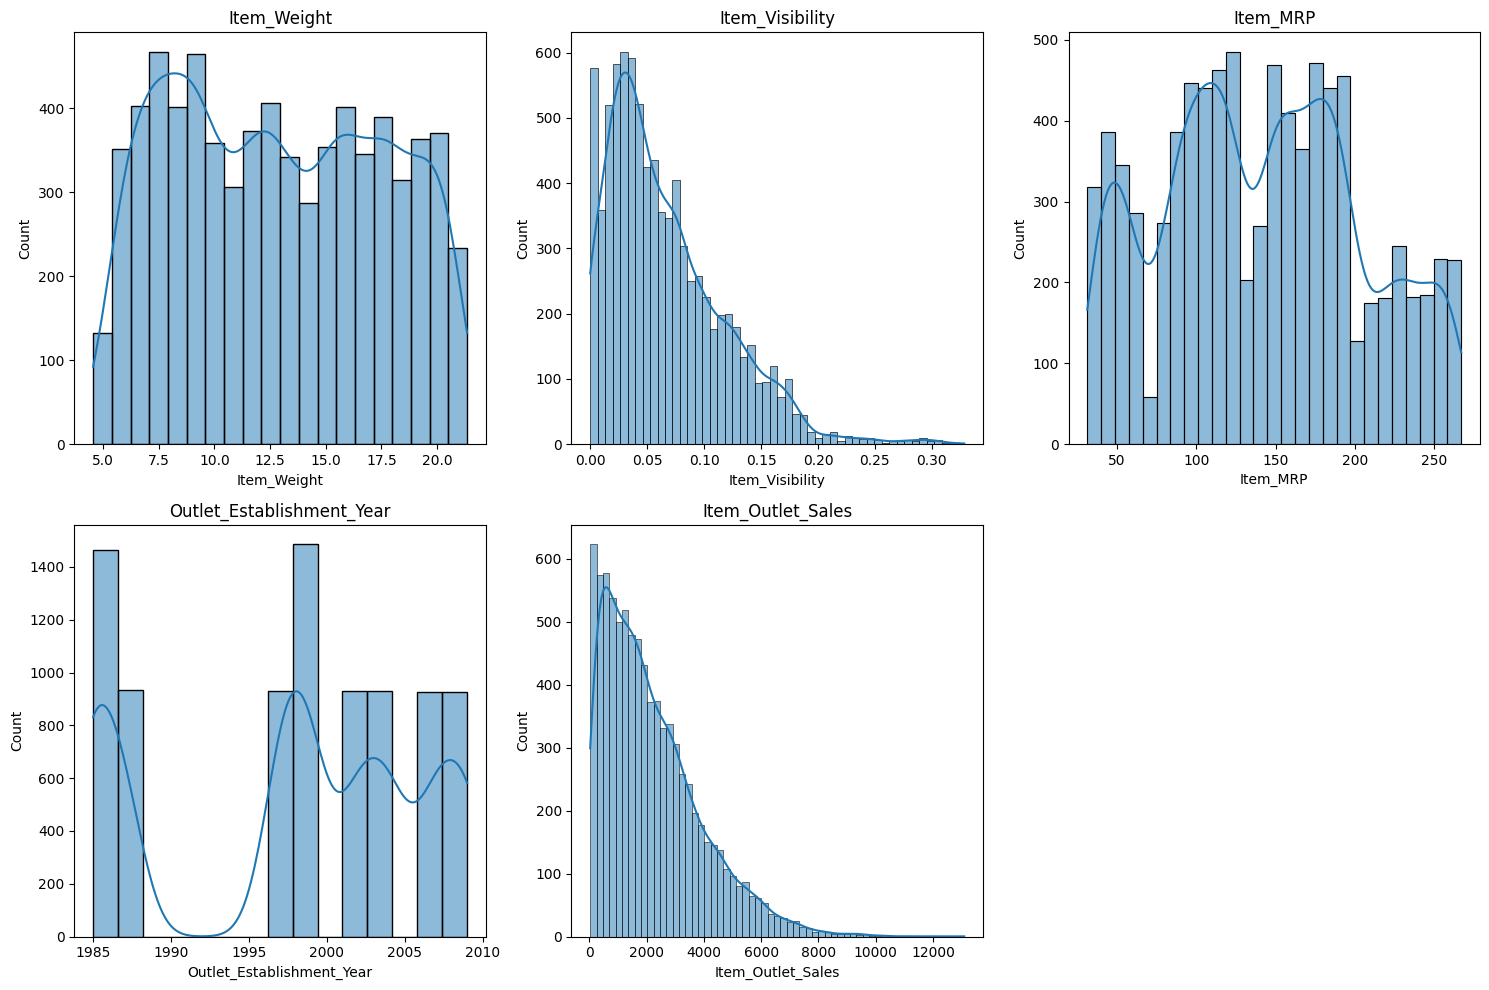

In [ ]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(num_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

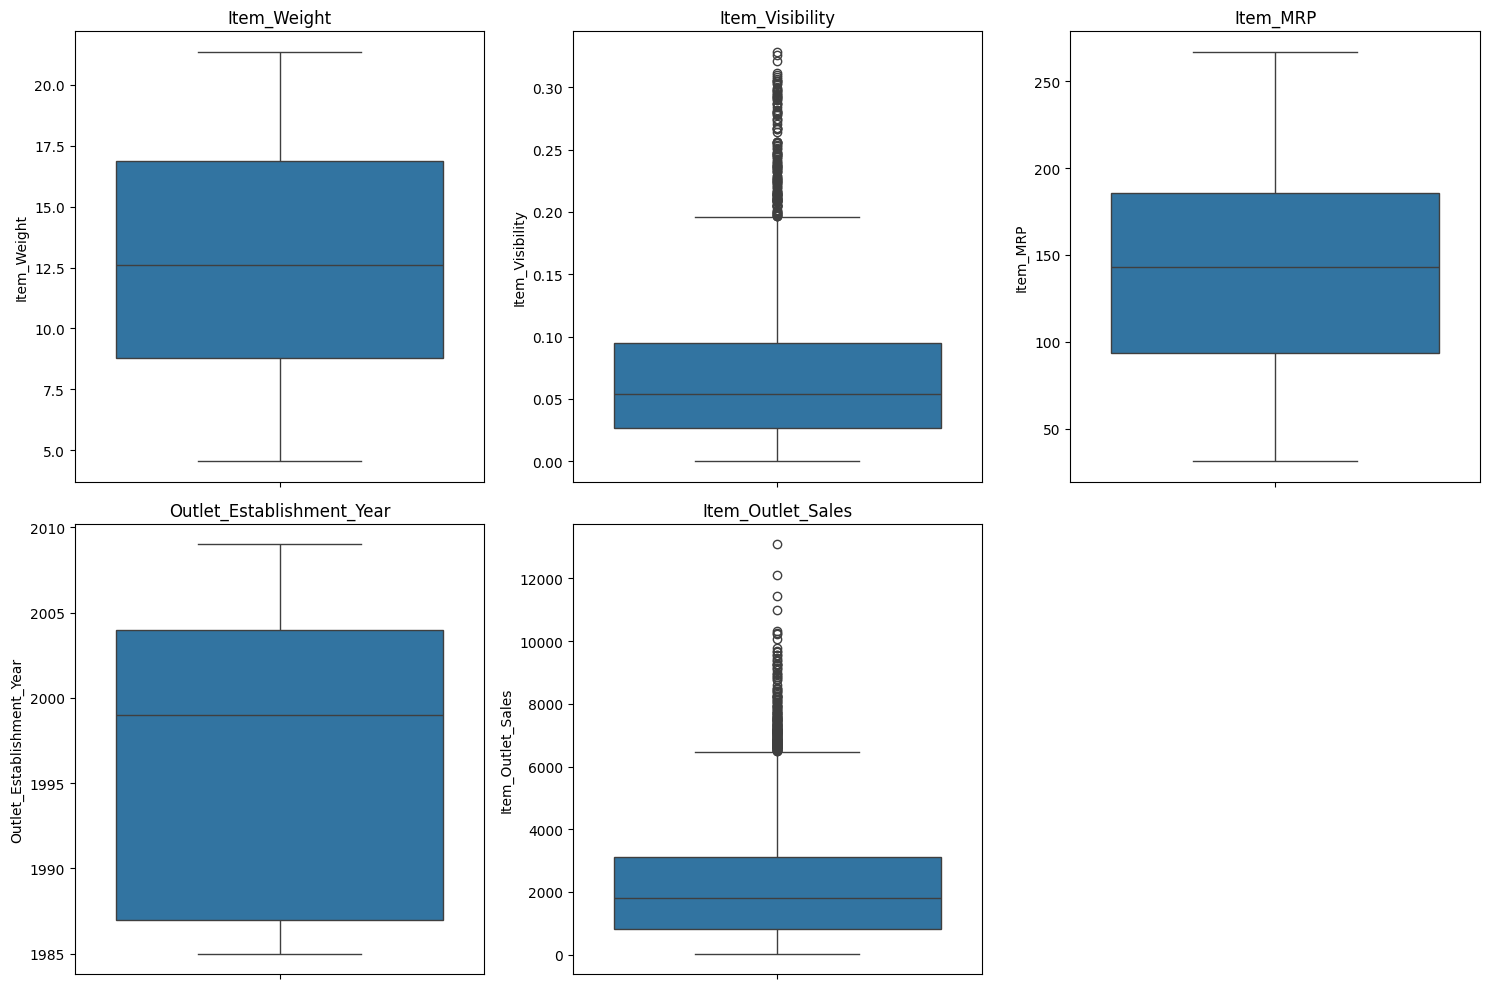

In [ ]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

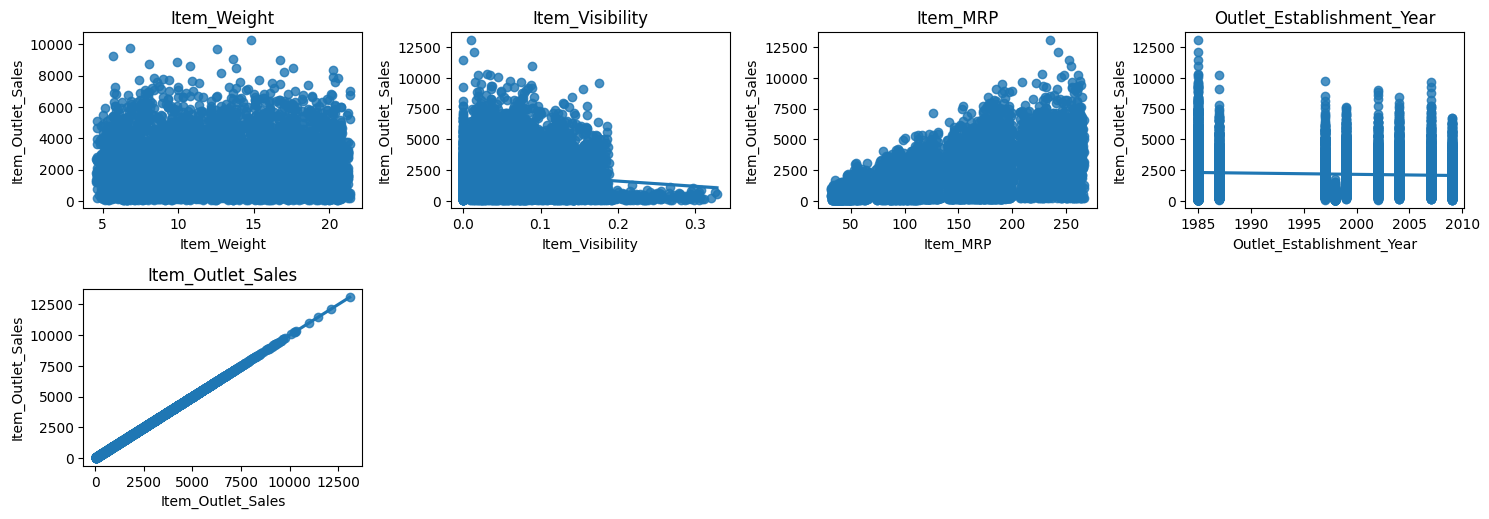

In [ ]:
num_cols = num_df.columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.regplot(x=df[col], y=df["Item_Outlet_Sales"])
    plt.title(col)
plt.tight_layout()
plt.show()

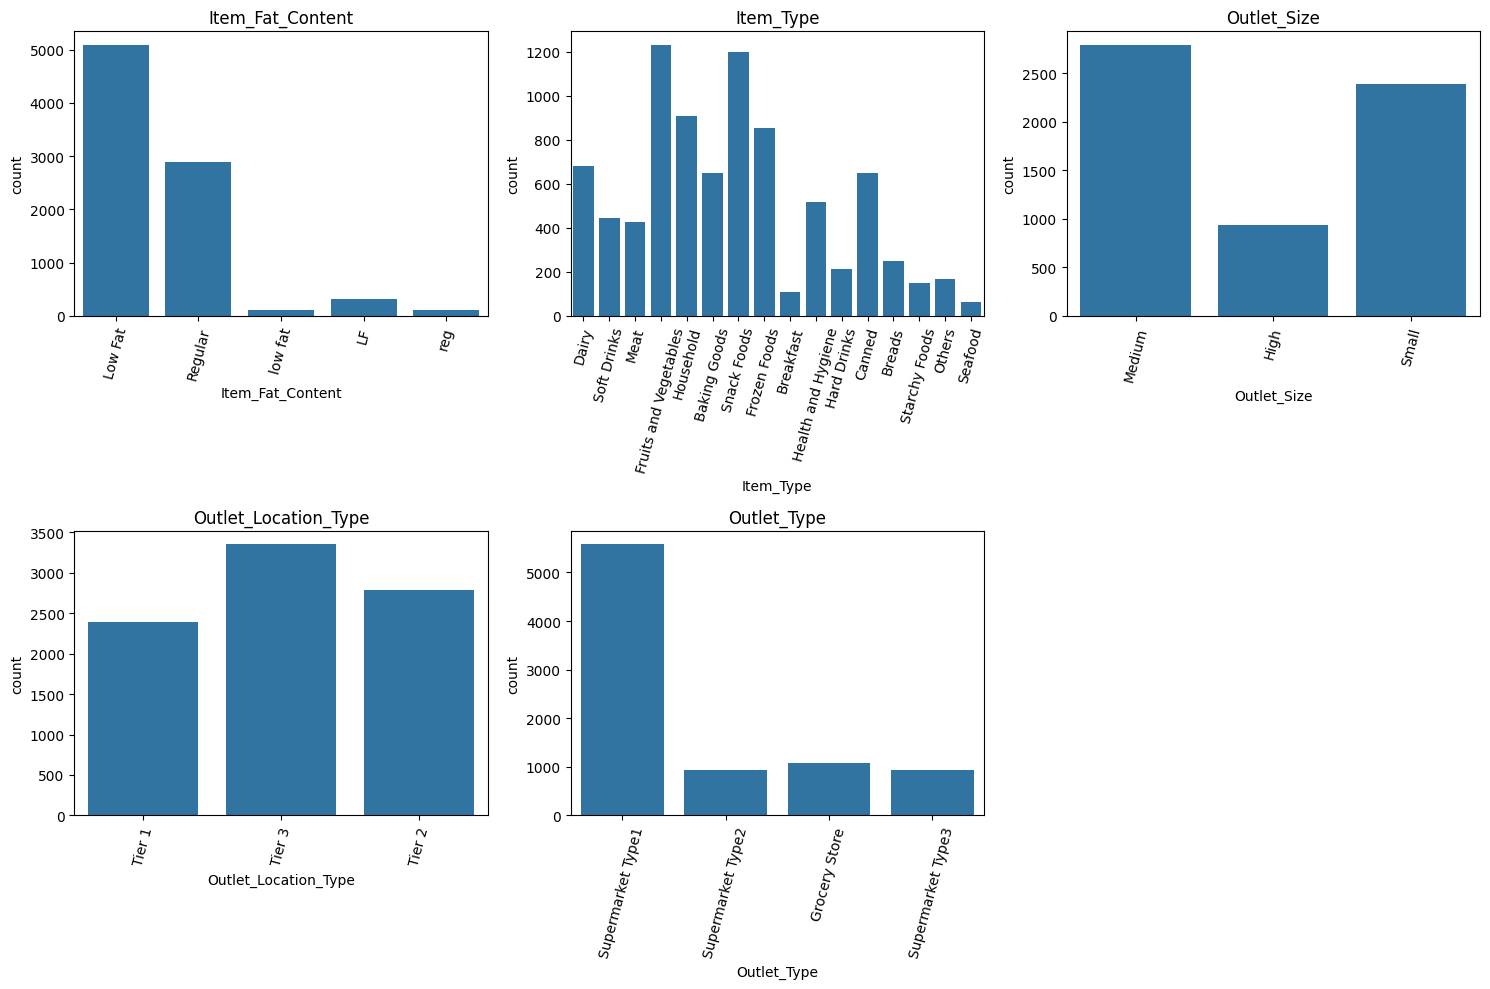

In [ ]:
cols = cat_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=cat_df[col])
    plt.title(col)
    plt.xticks(rotation=75)

plt.tight_layout()
plt.show()

# ***Data Preprocessing***

In [ ]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)

In [ ]:
num_df['Item_Weight'].fillna(num_df['Item_Weight'].median(), inplace=True)
cat_df['Outlet_Size'].fillna(cat_df['Outlet_Size'].mode()[0], inplace=True)

In [ ]:
num_df["Item_Outlet_Sales"]=np.log1p(num_df["Item_Outlet_Sales"])
num_df["Item_Visibility"]=np.log1p(num_df["Item_Visibility"])

In [ ]:
fat_map = {
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
}

cat_df['Item_Fat_Content'] = cat_df['Item_Fat_Content'].replace(fat_map)

print(cat_df['Item_Fat_Content'].nunique())

2


In [ ]:
encoder = LabelEncoder()
for col in cat_df:
    cat_df[col] = encoder.fit_transform(cat_df[col])

In [ ]:
df = pd.concat([num_df, cat_df], axis=1)
df.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content,Item_Type,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.30,0.015920,249.8092,1999,8.225808,0,4,1,0,1
1,5.92,0.019095,48.2692,2009,6.096776,1,14,1,2,2
2,17.50,0.016621,141.6180,1999,7.648868,0,10,1,0,1
3,19.20,0.000000,182.0950,1998,6.597664,1,6,1,2,0
4,8.93,0.000000,53.8614,1987,6.903451,0,9,0,2,1


In [ ]:
X=df.drop('Item_Outlet_Sales',axis=1)
y=df['Item_Outlet_Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [ ]:
models = {
    "LinearRegression": (
        LinearRegression(),
        {}
    ),
    "Lasso": (
        Lasso(),
        {"alpha": [0.01, 0.1, 1, 10]}
    ),
    "Ridge": (
        Ridge(),
        {"alpha": [0.01, 0.1, 1, 10]}
    ),
    "KNN": (
        KNeighborsRegressor(),
        {"n_neighbors": [3, 5, 7, 9]}
    ),
    "SVR": (
        SVR(),
        {"kernel": ["rbf"], "C": [1, 10], "gamma": ["scale", "auto"]}
    ),
    "DecisionTree": (
        DecisionTreeRegressor(random_state=42),
        {"max_depth": [None, 5, 10, 20]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
    ),
    "ExtraTrees": (
        ExtraTreesRegressor(random_state=42),
        {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]}
    ),
    "AdaBoost": (
        AdaBoostRegressor(random_state=42),
        {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1, 1]}
    ),
    "Bagging": (
        BaggingRegressor(random_state=42),
        {"n_estimators": [10, 50, 100]}
    ),
    "XGBoost": (
        XGBRegressor(random_state=42),
        {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 5]}
    ),
    "CatBoost": (
        CatBoostRegressor(random_state=42, verbose=0),
        {"iterations": [100, 200], "learning_rate": [0.01, 0.1], "depth": [4, 6]}
    ),
    "LightGBM": (
        LGBMRegressor(random_state=42),
        {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "num_leaves": [31, 50]}
    )
}


In [ ]:
results = []

results = []

for name, (model, params) in models.items():

    grid = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_


    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)


    results.append({
        "Model": name,
        "Train_R2": r2_score(y_train, y_train_pred),
        "Test_R2": r2_score(y_test, y_test_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Train_MAE": mean_absolute_error(y_train, y_train_pred),
        "Test_MAE": mean_absolute_error(y_test, y_test_pred),
        "Best_Params": grid.best_params_
    })

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000401 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 9
[LightGBM] [Info] Start training from score 7.305972


In [ ]:
results_df = pd.DataFrame(results).sort_values(by="Test_R2", ascending=False)
results_df

,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Best_Params
12,CatBoost,0.747446,0.747379,0.505906,0.513172,0.390549,0.397281,"{'depth': 4, 'iterations': 100, 'learning_rate..."
11,XGBoost,0.753230,0.744700,0.500079,0.515886,0.385903,0.400174,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
7,ExtraTrees,0.805552,0.743845,0.443909,0.516750,0.339725,0.400874,"{'max_depth': 10, 'n_estimators': 100}"
8,GradientBoosting,0.755662,0.743266,0.497609,0.517333,0.384110,0.401235,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
13,LightGBM,0.801749,0.741787,0.448229,0.518821,0.347758,0.401988,"{'learning_rate': 0.1, 'n_estimators': 100, 'n..."
6,RandomForest,0.820788,0.735934,0.426163,0.524668,0.330138,0.406652,"{'max_depth': 10, 'n_estimators': 100}"
5,DecisionTree,0.739794,0.733499,0.513513,0.527082,0.397320,0.408749,{'max_depth': 5}
10,Bagging,0.957653,0.718545,0.207158,0.541668,0.160193,0.423276,{'n_estimators': 100}
9,AdaBoost,0.703419,0.707701,0.548231,0.552004,0.437035,0.439216,"{'learning_rate': 0.1, 'n_estimators': 50}"
2,Ridge,0.579407,0.594165,0.652865,0.650434,0.517017,0.510285,{'alpha': 0.1}
